# Is This Trading Strategy Actually Profitable?

**A Rigorous Framework for Strategy Evaluation**

This notebook implements a production-ready framework for evaluating the profitability of a trading strategy. We move beyond backtesting heuristics to a principled expected value analysis that accounts for real-world frictions.

## Overview

Individual trades are noisy realizations of a stochastic process. A winning trade proves nothing; a losing trade proves nothing. The only reliable measure of profitability is **expected value per trade**:

$$\mathbb{E}[\text{P\&L}] = \sum_{i} p_i \cdot x_i$$

where $p_i$ is the probability of outcome $i$ and $x_i$ is the corresponding payoff.

### Mathematical Foundation

For a binary outcome strategy:
- **Win probability**: $p \in [0,1]$
- **Win payoff**: $W > 0$
- **Loss payoff**: $L > 0$ (amount lost)
- **Transaction cost**: $c \geq 0$

The expected value per trade is:

$$\mathbb{E}[\text{P\&L}] = p \cdot (W - c) + (1-p) \cdot (-L - c) = p \cdot W - (1-p) \cdot L - c$$

A strategy is **profitable** if and only if $\mathbb{E}[\text{P\&L}] > 0$.

### Why This Matters

- **Risk Management**: Know your edge before sizing positions
- **Strategy Selection**: Compare strategies on expected value, not win rate
- **Capital Allocation**: Kelly criterion and position sizing depend on EV
- **Due Diligence**: Quantify whether execution costs destroy your edge

## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
np.set_printoptions(precision=4, suppress=True)

print("Environment configured successfully.")

Environment configured successfully.


## 2. Strategy Representation

We represent a strategy as a parameter vector $\theta = (p, W, L, c)$ where:
- $p$: win probability
- $W$: win amount
- $L$: loss amount  
- $c$: cost per trade

This representation allows us to use linear algebra for efficient computation and enables vectorized analysis across multiple strategies.

In [2]:
def create_strategy_params(p_win: float, win_amount: float, 
                           loss_amount: float, cost: float) -> np.ndarray:
    """
    Create a strategy parameter vector.
    
    Parameters
    ----------
    p_win : float
        Probability of winning (0 to 1)
    win_amount : float
        Amount gained on a win (before costs)
    loss_amount : float
        Amount lost on a loss (before costs)
    cost : float
        Fixed transaction cost per trade
        
    Returns
    -------
    np.ndarray
        Parameter vector [p_win, win_amount, loss_amount, cost]
    """
    return np.array([p_win, win_amount, loss_amount, cost])

# Example: A typical mean-reversion strategy
# 60% win rate, $100 avg win, $80 avg loss, $5 round-trip cost
strategy = create_strategy_params(0.6, 100, 80, 5)
print(f"Strategy parameters: {strategy}")
print(f"  Win probability: {strategy[0]:.1%}")
print(f"  Win amount: ${strategy[1]:.0f}")
print(f"  Loss amount: ${strategy[2]:.0f}")
print(f"  Cost per trade: ${strategy[3]:.0f}")

Strategy parameters: [  0.6 100.   80.    5. ]
  Win probability: 60.0%
  Win amount: $100
  Loss amount: $80
  Cost per trade: $5


In [3]:
def build_outcome_vectors(params: np.ndarray) -> tuple:
    """
    Construct probability and payoff vectors for EV calculation.
    
    The dot product of these vectors gives the expected value:
    EV = probs @ payoffs
    
    Parameters
    ----------
    params : np.ndarray
        Strategy parameters [p_win, win_amount, loss_amount, cost]
        
    Returns
    -------
    tuple
        (probabilities, net_payoffs) - both as numpy arrays
    """
    p_win, win_amount, loss_amount, cost = params
    
    probabilities = np.array([p_win, 1 - p_win])
    net_payoffs = np.array([win_amount - cost, -loss_amount - cost])
    
    return probabilities, net_payoffs

# Demonstrate the vector representation
probs, payoffs = build_outcome_vectors(strategy)
print("Outcome Distribution:")
print(f"  Win:  P = {probs[0]:.1%}, Net P&L = ${payoffs[0]:.0f}")
print(f"  Loss: P = {probs[1]:.1%}, Net P&L = ${payoffs[1]:.0f}")

Outcome Distribution:
  Win:  P = 60.0%, Net P&L = $95
  Loss: P = 40.0%, Net P&L = $-85


## 3. Expected Value Computation

The expected value is the probability-weighted sum of outcomes. For two outcomes:

$$\mathbb{E}[X] = \sum_{i=1}^{2} p_i \cdot x_i = \mathbf{p}^\top \mathbf{x}$$

This is simply a dot product, making computation efficient and generalizable.

In [4]:
def expected_value(probs: np.ndarray, payoffs: np.ndarray) -> float:
    """
    Compute expected value using the dot product formulation.
    
    Parameters
    ----------
    probs : np.ndarray
        Probability vector (must sum to 1)
    payoffs : np.ndarray
        Corresponding payoff vector
        
    Returns
    -------
    float
        Expected value
    """
    return np.dot(probs, payoffs)

def ev_from_params(params: np.ndarray) -> float:
    """
    Compute expected value directly from strategy parameters.
    
    Using the analytical formula:
    EV = p * W - (1-p) * L - c
    
    Parameters
    ----------
    params : np.ndarray
        Strategy parameters [p_win, win_amount, loss_amount, cost]
        
    Returns
    -------
    float
        Expected value per trade
    """
    p_win, win_amount, loss_amount, cost = params
    return p_win * win_amount - (1 - p_win) * loss_amount - cost

# Compute EV both ways
ev_dot = expected_value(probs, payoffs)
ev_direct = ev_from_params(strategy)

print("Expected Value Computation:")
print(f"  Dot product method:  ${ev_dot:.2f}")
print(f"  Direct formula:      ${ev_direct:.2f}")
print(f"  Consistency check:   {np.isclose(ev_dot, ev_direct)}")

Expected Value Computation:
  Dot product method:  $23.00
  Direct formula:      $23.00
  Consistency check:   True


In [5]:
def batch_ev(params_matrix: np.ndarray) -> np.ndarray:
    """
    Vectorized EV computation for multiple strategies.
    
    Parameters
    ----------
    params_matrix : np.ndarray
        Matrix where each row is [p_win, win, loss, cost]
        Shape: (n_strategies, 4)
        
    Returns
    -------
    np.ndarray
        Vector of expected values, one per strategy
    """
    p_wins = params_matrix[:, 0]
    win_amounts = params_matrix[:, 1]
    loss_amounts = params_matrix[:, 2]
    costs = params_matrix[:, 3]
    
    return p_wins * win_amounts - (1 - p_wins) * loss_amounts - costs

# Compare multiple strategies
strategies = np.array([
    [0.6, 100, 80, 5],    # Baseline
    [0.5, 50, 50, 0],     # Fair game
    [0.7, 80, 120, 8],    # High win rate
    [0.3, 200, 50, 10],   # Low probability, high reward
])

evs = batch_ev(strategies)
print("Strategy Comparison:")
print("-" * 50)
for i, (params, ev) in enumerate(zip(strategies, evs)):
    status = "PROFITABLE" if ev > 0 else "UNPROFITABLE"
    print(f"Strategy {i+1}: p={params[0]:.0%}, W=${params[1]:.0f}, L=${params[2]:.0f}, c=${params[3]:.0f}")
    print(f"           EV = ${ev:.2f} [{status}]")

Strategy Comparison:
--------------------------------------------------
Strategy 1: p=60%, W=$100, L=$80, c=$5
           EV = $23.00 [PROFITABLE]
Strategy 2: p=50%, W=$50, L=$50, c=$0
           EV = $0.00 [UNPROFITABLE]
Strategy 3: p=70%, W=$80, L=$120, c=$8
           EV = $12.00 [PROFITABLE]
Strategy 4: p=30%, W=$200, L=$50, c=$10
           EV = $15.00 [PROFITABLE]


## 4. Break-Even Analysis

Understanding break-even points reveals how robust your edge is. We derive the minimum win probability required for $\mathbb{E}[\text{P\&L}] = 0$.

### Derivation

Setting $\mathbb{E}[\text{P\&L}] = 0$:

$$p \cdot W - (1-p) \cdot L - c = 0$$
$$p \cdot W - L + p \cdot L - c = 0$$
$$p \cdot (W + L) = L + c$$
$$p^* = \frac{L + c}{W + L}$$

This is the **break-even win probability**. Any $p > p^*$ yields positive EV.

In [6]:
def break_even_probability(win_amount: float, loss_amount: float, 
                           cost: float) -> float:
    """
    Calculate minimum win probability for EV = 0.
    
    Parameters
    ----------
    win_amount : float
        Amount gained on a win
    loss_amount : float
        Amount lost on a loss
    cost : float
        Transaction cost per trade
        
    Returns
    -------
    float
        Break-even win probability
    """
    return (loss_amount + cost) / (win_amount + loss_amount)

def break_even_win_amount(p_win: float, loss_amount: float, 
                          cost: float) -> float:
    """
    Calculate minimum win size for EV = 0.
    
    From EV = 0:
    W = ((1-p) * L + c) / p
    """
    return ((1 - p_win) * loss_amount + cost) / p_win

# Analyze our baseline strategy
be_prob = break_even_probability(100, 80, 5)
actual_prob = 0.6
margin = actual_prob - be_prob

print("Break-Even Analysis:")
print(f"  Break-even probability: {be_prob:.2%}")
print(f"  Actual probability:     {actual_prob:.2%}")
print(f"  Margin above break-even: {margin:.2%}")
print(f"  Status: {'SAFE' if margin > 0.05 else 'MARGINAL' if margin > 0 else 'UNPROFITABLE'}")

Break-Even Analysis:
  Break-even probability: 47.22%
  Actual probability:     60.00%
  Margin above break-even: 12.78%
  Status: SAFE


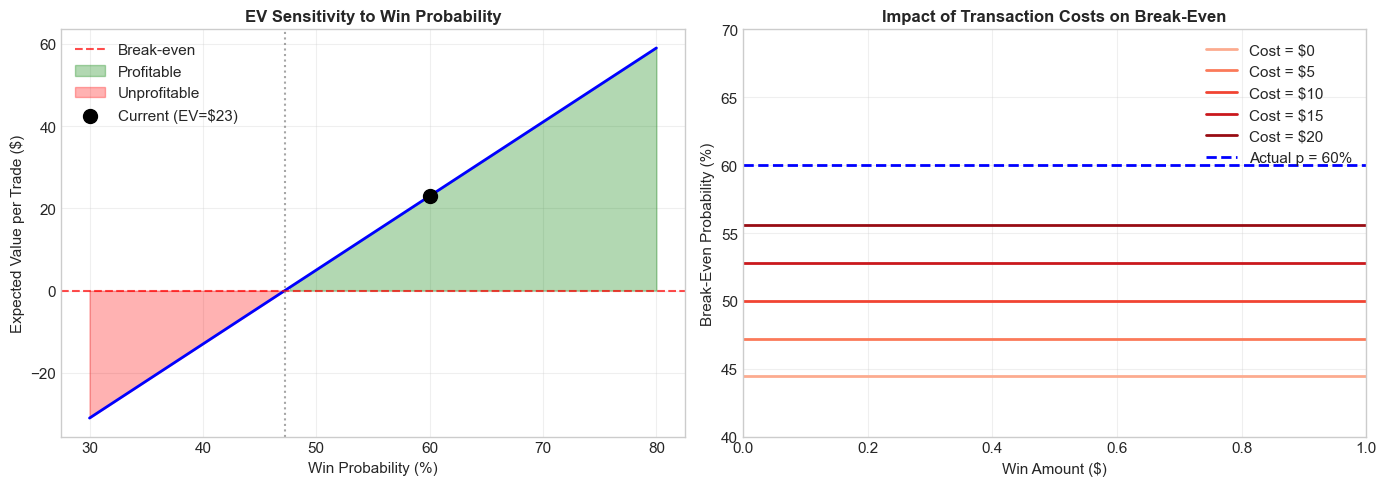

In [7]:
# Sensitivity analysis: How EV changes with win probability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: EV vs win probability
p_range = np.linspace(0.3, 0.8, 100)
evs = p_range * 100 - (1 - p_range) * 80 - 5

axes[0].plot(p_range * 100, evs, 'b-', linewidth=2)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Break-even')
axes[0].axvline(x=be_prob * 100, color='gray', linestyle=':', alpha=0.7)
axes[0].fill_between(p_range * 100, evs, 0, where=(evs > 0), alpha=0.3, color='green', label='Profitable')
axes[0].fill_between(p_range * 100, evs, 0, where=(evs < 0), alpha=0.3, color='red', label='Unprofitable')
axes[0].scatter([60], [23], color='black', s=100, zorder=5, label=f'Current (EV=${23:.0f})')
axes[0].set_xlabel('Win Probability (%)')
axes[0].set_ylabel('Expected Value per Trade ($)')
axes[0].set_title('EV Sensitivity to Win Probability', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Break-even surface for different cost levels
costs = [0, 5, 10, 15, 20]
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(costs)))

for cost, color in zip(costs, colors):
    be_probs = [(80 + cost) / 180] * 100
    axes[1].axhline(y=(80 + cost) / 180 * 100, color=color, linewidth=2, label=f'Cost = ${cost}')

axes[1].axhline(y=60, color='blue', linestyle='--', linewidth=2, label='Actual p = 60%')
axes[1].set_xlabel('Win Amount ($)')
axes[1].set_ylabel('Break-Even Probability (%)')
axes[1].set_title('Impact of Transaction Costs on Break-Even', fontsize=12, fontweight='bold')
axes[1].set_ylim(40, 70)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Monte Carlo Simulation

While expected value is the truth, simulation builds intuition about variance and path dependency. We simulate many independent trading sequences to observe:

1. **Convergence to EV**: By the Law of Large Numbers, $\bar{X}_n \xrightarrow{P} \mathbb{E}[X]$
2. **Variance of outcomes**: Even positive EV strategies have losing sequences
3. **Drawdown distributions**: Practical risk beyond expected value

In [8]:
def simulate_outcomes(p_win: float, n_trades: int, seed: int = None) -> np.ndarray:
    """
    Generate random trade outcomes.
    
    Parameters
    ----------
    p_win : float
        Probability of winning each trade
    n_trades : int
        Number of trades to simulate
    seed : int, optional
        Random seed for reproducibility
        
    Returns
    -------
    np.ndarray
        Array of outcomes (1 = win, 0 = loss)
    """
    rng = np.random.default_rng(seed)
    return (rng.random(n_trades) < p_win).astype(int)

def simulate_pnl_path(params: np.ndarray, n_trades: int, 
                      seed: int = None) -> tuple:
    """
    Simulate a trading sequence and return cumulative P&L.
    
    Parameters
    ----------
    params : np.ndarray
        Strategy parameters [p_win, win_amount, loss_amount, cost]
    n_trades : int
        Number of trades to simulate
    seed : int, optional
        Random seed
        
    Returns
    -------
    tuple
        (outcomes, trade_pnls, cumulative_pnl)
    """
    p_win, win_amount, loss_amount, cost = params
    
    outcomes = simulate_outcomes(p_win, n_trades, seed)
    
    win_pnl = win_amount - cost
    loss_pnl = -loss_amount - cost
    
    trade_pnls = np.where(outcomes == 1, win_pnl, loss_pnl)
    cumulative_pnl = np.cumsum(trade_pnls)
    
    return outcomes, trade_pnls, cumulative_pnl

# Single path visualization
outcomes, pnls, cum_pnl = simulate_pnl_path(strategy, 200, seed=42)
theoretical_ev = ev_from_params(strategy)

print(f"Simulation Results (200 trades):")
print(f"  Win rate (realized):  {outcomes.mean():.1%}")
print(f"  Mean P&L per trade:   ${pnls.mean():.2f}")
print(f"  Theoretical EV:       ${theoretical_ev:.2f}")
print(f"  Final P&L:            ${cum_pnl[-1]:.0f}")
print(f"  Theoretical expectation: ${theoretical_ev * 200:.0f}")

Simulation Results (200 trades):
  Win rate (realized):  61.5%
  Mean P&L per trade:   $25.70
  Theoretical EV:       $23.00
  Final P&L:            $5140
  Theoretical expectation: $4600


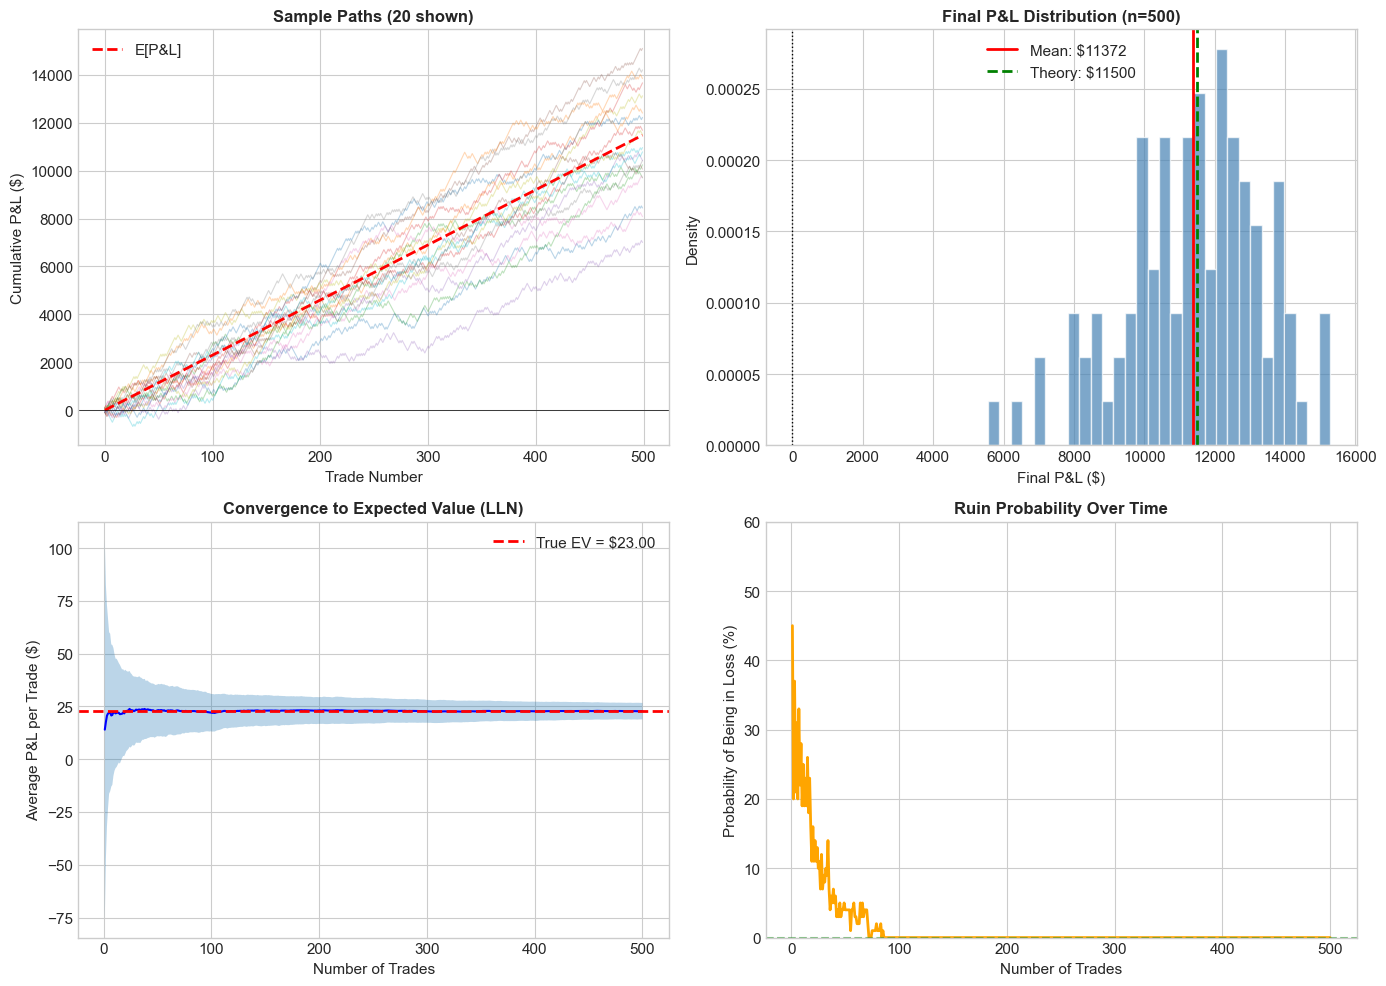


Simulation Statistics (100 paths, 500 trades each):
  Mean final P&L:     $11372
  Std of final P&L:   $1963
  % profitable paths: 100.0%
  5th percentile:     $7900
  95th percentile:    $14200


In [9]:
# Visualize multiple paths
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

n_trades = 500
n_paths = 100
paths = np.zeros((n_paths, n_trades))

for i in range(n_paths):
    _, _, cum_pnl = simulate_pnl_path(strategy, n_trades, seed=i)
    paths[i] = cum_pnl

# Top left: Sample paths
for i in range(min(20, n_paths)):
    axes[0, 0].plot(paths[i], alpha=0.3, linewidth=0.8)
axes[0, 0].plot(np.arange(n_trades) * theoretical_ev, 'r--', linewidth=2, label='E[P&L]')
axes[0, 0].axhline(y=0, color='black', linewidth=0.5)
axes[0, 0].set_xlabel('Trade Number')
axes[0, 0].set_ylabel('Cumulative P&L ($)')
axes[0, 0].set_title('Sample Paths (20 shown)', fontsize=12, fontweight='bold')
axes[0, 0].legend()

# Top right: Final P&L distribution
final_pnls = paths[:, -1]
axes[0, 1].hist(final_pnls, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes[0, 1].axvline(x=final_pnls.mean(), color='red', linestyle='-', linewidth=2, label=f'Mean: ${final_pnls.mean():.0f}')
axes[0, 1].axvline(x=theoretical_ev * n_trades, color='green', linestyle='--', linewidth=2, label=f'Theory: ${theoretical_ev * n_trades:.0f}')
axes[0, 1].axvline(x=0, color='black', linestyle=':', linewidth=1)
axes[0, 1].set_xlabel('Final P&L ($)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title(f'Final P&L Distribution (n={n_trades})', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# Bottom left: Convergence of mean
running_means = paths.mean(axis=0)
running_stds = paths.std(axis=0)
trade_nums = np.arange(1, n_trades + 1)

per_trade_means = running_means / trade_nums

axes[1, 0].plot(trade_nums, per_trade_means, 'b-', linewidth=1.5)
axes[1, 0].axhline(y=theoretical_ev, color='red', linestyle='--', linewidth=2, label=f'True EV = ${theoretical_ev:.2f}')
axes[1, 0].fill_between(trade_nums, per_trade_means - running_stds/trade_nums, 
                        per_trade_means + running_stds/trade_nums, alpha=0.3)
axes[1, 0].set_xlabel('Number of Trades')
axes[1, 0].set_ylabel('Average P&L per Trade ($)')
axes[1, 0].set_title('Convergence to Expected Value (LLN)', fontsize=12, fontweight='bold')
axes[1, 0].legend()

# Bottom right: Probability of loss
prob_loss = (paths < 0).mean(axis=0)
axes[1, 1].plot(trade_nums, prob_loss * 100, 'orange', linewidth=2)
axes[1, 1].axhline(y=0, color='green', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Number of Trades')
axes[1, 1].set_ylabel('Probability of Being in Loss (%)')
axes[1, 1].set_title('Ruin Probability Over Time', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim(0, 60)

plt.tight_layout()
plt.show()

print(f"\nSimulation Statistics ({n_paths} paths, {n_trades} trades each):")
print(f"  Mean final P&L:     ${final_pnls.mean():.0f}")
print(f"  Std of final P&L:   ${final_pnls.std():.0f}")
print(f"  % profitable paths: {(final_pnls > 0).mean() * 100:.1f}%")
print(f"  5th percentile:     ${np.percentile(final_pnls, 5):.0f}")
print(f"  95th percentile:    ${np.percentile(final_pnls, 95):.0f}")

## 6. Stress Testing

Your strategy has positive expected value. Congratulations - on paper. But paper ignores reality.

**Stress testing** asks: does your edge survive when things go wrong? Real markets have frictions, surprises, and costs that your simple model doesn't capture.

### Friction 1: Slippage

**Slippage** is the difference between expected and actual execution price. Causes include:
- Market movement during order processing
- Large orders pushing prices
- Low liquidity

**Model**: Subtract average slippage from EV as an additional cost:
$$\text{EV}_{\text{adj}} = \text{EV}_{\text{base}} - \text{slippage}$$

### Friction 2: Tail Risk

**Tail risk** refers to rare catastrophic events your basic model ignores. Your strategy assumes losses are capped at $L$, but what about flash crashes?

**Model**: Add a third outcome with probability $p_{\text{tail}}$ and catastrophic loss $L_{\text{tail}} \gg L$:

$$\text{EV}_{\text{tail}} = p_w(1-p_{\text{tail}})(W-c) + (1-p_w)(1-p_{\text{tail}})(-L-c) + p_{\text{tail}}(-L_{\text{tail}}-c)$$

In [10]:
def ev_with_slippage(params: np.ndarray, avg_slippage: float) -> tuple:
    """
    Compute EV after accounting for execution slippage.
    
    Parameters
    ----------
    params : np.ndarray
        Strategy parameters
    avg_slippage : float
        Average slippage cost per trade
        
    Returns
    -------
    tuple
        (base_ev, adjusted_ev, slippage_impact)
    """
    base_ev = ev_from_params(params)
    adjusted_ev = base_ev - avg_slippage
    return base_ev, adjusted_ev, -avg_slippage

def ev_with_tail_risk(params: np.ndarray, tail_prob: float, 
                      tail_loss: float) -> tuple:
    """
    Compute EV accounting for rare large losses.
    
    Parameters
    ----------
    params : np.ndarray
        Strategy parameters
    tail_prob : float
        Probability of tail event (e.g., 0.02 for 2%)
    tail_loss : float
        Magnitude of tail loss
        
    Returns
    -------
    tuple
        (base_ev, adjusted_ev, tail_impact)
    """
    p_win, win_amount, loss_amount, cost = params
    
    base_ev = ev_from_params(params)
    
    remaining = 1 - tail_prob
    adj_p_win = p_win * remaining
    adj_p_loss = (1 - p_win) * remaining
    
    adjusted_ev = (adj_p_win * (win_amount - cost) +
                   adj_p_loss * (-loss_amount - cost) +
                   tail_prob * (-tail_loss - cost))
    
    return base_ev, adjusted_ev, adjusted_ev - base_ev

# Test individual stress factors
print("Individual Stress Factors:")
print("=" * 50)

base, adj, impact = ev_with_slippage(strategy, 2.0)
print(f"Slippage ($2/trade): EV ${base:.2f} -> ${adj:.2f} (impact: ${impact:.2f})")

base, adj, impact = ev_with_tail_risk(strategy, 0.02, 500)
print(f"Tail risk (2%, $500): EV ${base:.2f} -> ${adj:.2f} (impact: ${impact:.2f})")

Individual Stress Factors:
Slippage ($2/trade): EV $23.00 -> $21.00 (impact: $-2.00)
Tail risk (2%, $500): EV $23.00 -> $12.44 (impact: $-10.56)


In [11]:
def stress_test(params: np.ndarray, avg_slippage: float, 
                tail_prob: float, tail_loss: float) -> tuple:
    """
    Run comprehensive stress test on a strategy.
    
    Applies both slippage and tail risk adjustments.
    
    Parameters
    ----------
    params : np.ndarray
        Strategy parameters
    avg_slippage : float
        Average slippage per trade
    tail_prob : float
        Probability of tail event
    tail_loss : float
        Magnitude of tail loss
        
    Returns
    -------
    tuple
        (base_ev, stressed_ev, survives)
    """
    p_win, win_amount, loss_amount, cost = params
    
    base_ev = ev_from_params(params)
    
    # Apply tail risk
    remaining = 1 - tail_prob
    adj_p_win = p_win * remaining
    adj_p_loss = (1 - p_win) * remaining
    
    ev_with_tail = (adj_p_win * (win_amount - cost) +
                    adj_p_loss * (-loss_amount - cost) +
                    tail_prob * (-tail_loss - cost))
    
    # Apply slippage
    stressed_ev = ev_with_tail - avg_slippage
    
    survives = stressed_ev > 0
    
    return base_ev, stressed_ev, survives

# Stress test the strategy
print("\nComprehensive Stress Test:")
print("=" * 50)

base, stressed, survives = stress_test(strategy, 2.0, 0.02, 500)
print(f"Base EV:     ${base:.2f}")
print(f"Stressed EV: ${stressed:.2f}")
print(f"Survives:    {'YES' if survives else 'NO'}")
print(f"EV degradation: {(1 - stressed/base)*100:.1f}%")


Comprehensive Stress Test:
Base EV:     $23.00
Stressed EV: $10.44
Survives:    YES
EV degradation: 54.6%


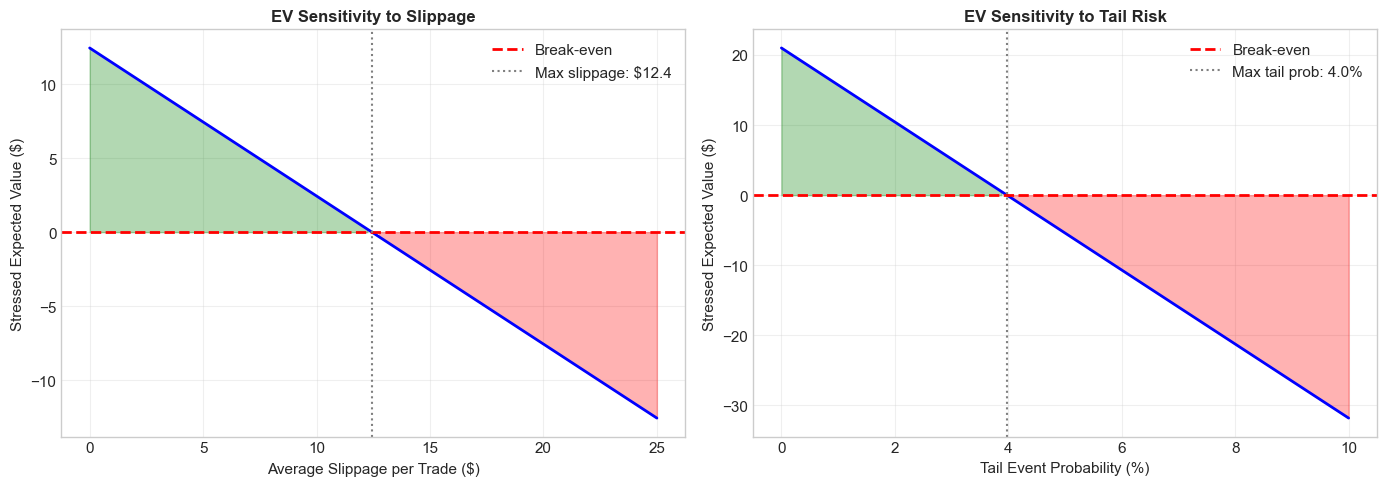


Robustness Thresholds:
  Maximum tolerable slippage: $12.44 per trade
  Maximum tolerable tail prob: 3.98%


In [12]:
# Stress test sensitivity analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: EV vs slippage
slippage_range = np.linspace(0, 25, 50)
evs_slippage = [stress_test(strategy, s, 0.02, 500)[1] for s in slippage_range]

axes[0].plot(slippage_range, evs_slippage, 'b-', linewidth=2)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Break-even')
axes[0].fill_between(slippage_range, evs_slippage, 0, 
                     where=np.array(evs_slippage) > 0, alpha=0.3, color='green')
axes[0].fill_between(slippage_range, evs_slippage, 0, 
                     where=np.array(evs_slippage) < 0, alpha=0.3, color='red')

# Find break-even slippage
be_slippage = np.interp(0, evs_slippage[::-1], slippage_range[::-1])
axes[0].axvline(x=be_slippage, color='gray', linestyle=':', label=f'Max slippage: ${be_slippage:.1f}')

axes[0].set_xlabel('Average Slippage per Trade ($)')
axes[0].set_ylabel('Stressed Expected Value ($)')
axes[0].set_title('EV Sensitivity to Slippage', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: EV vs tail probability
tail_prob_range = np.linspace(0, 0.10, 50)
evs_tail = [stress_test(strategy, 2.0, tp, 500)[1] for tp in tail_prob_range]

axes[1].plot(tail_prob_range * 100, evs_tail, 'b-', linewidth=2)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Break-even')
axes[1].fill_between(tail_prob_range * 100, evs_tail, 0, 
                     where=np.array(evs_tail) > 0, alpha=0.3, color='green')
axes[1].fill_between(tail_prob_range * 100, evs_tail, 0, 
                     where=np.array(evs_tail) < 0, alpha=0.3, color='red')

# Find break-even tail probability
be_tail = np.interp(0, evs_tail[::-1], tail_prob_range[::-1])
axes[1].axvline(x=be_tail * 100, color='gray', linestyle=':', label=f'Max tail prob: {be_tail:.1%}')

axes[1].set_xlabel('Tail Event Probability (%)')
axes[1].set_ylabel('Stressed Expected Value ($)')
axes[1].set_title('EV Sensitivity to Tail Risk', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRobustness Thresholds:")
print(f"  Maximum tolerable slippage: ${be_slippage:.2f} per trade")
print(f"  Maximum tolerable tail prob: {be_tail:.2%}")

## 7. Final Trading Decision

The decision rule is simple:
- **TRADE** if $\text{EV}_{\text{stressed}} > 0$
- **DO NOT TRADE** otherwise

No win rate, no backtest, no intuition overrides this rule. Expected value after all costs and risks is the only criterion.

In [13]:
def trading_decision(params: np.ndarray, avg_slippage: float, 
                     tail_prob: float, tail_loss: float) -> dict:
    """
    Make final trading decision with comprehensive analysis.
    
    Parameters
    ----------
    params : np.ndarray
        Strategy parameters [p_win, win_amount, loss_amount, cost]
    avg_slippage : float
        Average slippage per trade
    tail_prob : float
        Probability of tail event
    tail_loss : float
        Magnitude of tail loss
        
    Returns
    -------
    dict
        Complete analysis results
    """
    p_win, win_amount, loss_amount, cost = params
    
    # Basic analysis
    base_ev = ev_from_params(params)
    break_even_p = break_even_probability(win_amount, loss_amount, cost)
    margin = p_win - break_even_p
    
    # Stress test
    _, stressed_ev, survives = stress_test(params, avg_slippage, tail_prob, tail_loss)
    
    return {
        'p_win': p_win,
        'win_amount': win_amount,
        'loss_amount': loss_amount,
        'cost': cost,
        'base_ev': base_ev,
        'break_even_prob': break_even_p,
        'margin': margin,
        'stressed_ev': stressed_ev,
        'verdict': 'TRADE' if survives else 'DO NOT TRADE',
        'survives': survives
    }

# Make the decision
result = trading_decision(strategy, 2.0, 0.02, 500)

print("=" * 60)
print("STRATEGY EVALUATION REPORT")
print("=" * 60)
print(f"\nStrategy Parameters:")
print(f"  Win probability:    {result['p_win']:.1%}")
print(f"  Win amount:         ${result['win_amount']:.0f}")
print(f"  Loss amount:        ${result['loss_amount']:.0f}")
print(f"  Cost per trade:     ${result['cost']:.0f}")
print(f"\nExpected Value Analysis:")
print(f"  Base EV:            ${result['base_ev']:.2f}")
print(f"  Break-even prob:    {result['break_even_prob']:.1%}")
print(f"  Margin above BE:    {result['margin']:.2%}")
print(f"\nStress Test Results:")
print(f"  Stressed EV:        ${result['stressed_ev']:.2f}")
print(f"  EV degradation:     {(1 - result['stressed_ev']/result['base_ev'])*100:.1f}%")
print("\n" + "=" * 60)
print(f"VERDICT: {result['verdict']}")
if result['survives']:
    print(f"Positive EV of ${result['stressed_ev']:.2f} per trade after stress")
else:
    print(f"Negative EV of ${result['stressed_ev']:.2f} per trade under stress")
print("=" * 60)

STRATEGY EVALUATION REPORT

Strategy Parameters:
  Win probability:    60.0%
  Win amount:         $100
  Loss amount:        $80
  Cost per trade:     $5

Expected Value Analysis:
  Base EV:            $23.00
  Break-even prob:    47.2%
  Margin above BE:    12.78%

Stress Test Results:
  Stressed EV:        $10.44
  EV degradation:     54.6%

VERDICT: TRADE
Positive EV of $10.44 per trade after stress


## 8. Complete Pipeline Demonstration

Let's run the complete analysis on a realistic strategy.

In [14]:
# ============================================================
# COMPLETE STRATEGY EVALUATION PIPELINE
# ============================================================

# Define strategy to evaluate
params = np.array([0.55, 120, 100, 8])

# Stress parameters (realistic estimates)
avg_slippage = 1.7
tail_prob = 0.02  # 2% chance of tail event
tail_loss = 400   # 4x normal loss in tail event

# ============================================================
# STEP 1: Basic Analysis
# ============================================================

p_win, win_amount, loss_amount, cost = params
base_ev = ev_from_params(params)
be_prob = break_even_probability(win_amount, loss_amount, cost)
margin = p_win - be_prob

print("=" * 60)
print("STRATEGY EVALUATION REPORT")
print("=" * 60)
print(f"Win probability:    {p_win*100:.1f}%")
print(f"Win amount:         ${win_amount}")
print(f"Loss amount:        ${loss_amount}")
print(f"Cost per trade:     ${cost}")
print(f"Base EV per trade:  ${base_ev:.2f}")
print(f"Break-even prob:    {be_prob*100:.1f}%")
print(f"Margin above break: {margin*100:.1f}%")

# ============================================================
# STEP 2: Stress Testing
# ============================================================

_, stressed_ev, survives = stress_test(params, avg_slippage, tail_prob, tail_loss)

print(f"\nStress Parameters:")
print(f"Slippage per trade: ${avg_slippage}")
print(f"Tail probability:   {tail_prob*100:.1f}%")
print(f"Tail loss:          ${tail_loss}")
print(f"Stressed EV:        ${stressed_ev:.2f}")

# ============================================================
# STEP 3: Monte Carlo Verification
# ============================================================

n_trades = 1000
n_trials = 500

rng = np.random.default_rng(42)
outcomes = (rng.random((n_trials, n_trades)) < p_win).astype(int)
win_pnl = win_amount - cost
loss_pnl = -loss_amount - cost
trade_pnls = np.where(outcomes == 1, win_pnl, loss_pnl)
final_pnls = np.sum(trade_pnls, axis=1)

print(f"\nMonte Carlo ({n_trials} trials x {n_trades} trades):")
print(f"Theoretical total:  ${base_ev * n_trades:.0f}")
print(f"Simulated mean:     ${np.mean(final_pnls):.0f}")
print(f"Simulated std:      ${np.std(final_pnls):.0f}")
print(f"% profitable runs:  {np.mean(final_pnls > 0)*100:.1f}%")

# ============================================================
# STEP 4: Final Verdict
# ============================================================

print("\n" + "=" * 60)
if stressed_ev > 0:
    print("VERDICT: TRADE")
    print(f"Positive EV of ${stressed_ev:.2f} per trade after stress")
else:
    print("VERDICT: DO NOT TRADE")
    print(f"Negative EV of ${stressed_ev:.2f} per trade under stress")
print("=" * 60)

STRATEGY EVALUATION REPORT
Win probability:    55.0%
Win amount:         $120.0
Loss amount:        $100.0
Cost per trade:     $8.0
Base EV per trade:  $13.00
Break-even prob:    49.1%
Margin above break: 5.9%

Stress Parameters:
Slippage per trade: $1.7
Tail probability:   2.0%
Tail loss:          $400
Stressed EV:        $2.88

Monte Carlo (500 trials x 1000 trades):
Theoretical total:  $13000
Simulated mean:     $13239
Simulated std:      $3306
% profitable runs:  100.0%

VERDICT: TRADE
Positive EV of $2.88 per trade after stress


## 9. Summary and Conclusions

Through this analysis, we developed a complete **strategy evaluation toolkit**:

| Component | Purpose |
|-----------|--------|
| Strategy Representation | Parameters as vectors for efficient computation |
| Expected Value Engine | The single number that determines profitability |
| Break-Even Analysis | Understanding margins and parameter sensitivity |
| Monte Carlo Simulation | Verification and variance intuition |
| Stress Testing | Survival under slippage and tail risk |
| Decision Function | Binary TRADE / DO NOT TRADE verdict |

### Key Principles

1. **Expected value per trade is the only metric that determines long-run profitability**
   - Win rate alone is meaningless without payoff sizes
   - Costs are certain; wins are probabilistic

2. **Stress testing is non-negotiable**
   - Paper profits ignore execution friction
   - Tail events can destroy months of gains

3. **The decision is binary**
   - Positive stressed EV: Trade
   - Negative stressed EV: Do not trade
   - No exceptions, no intuition overrides

---

*This notebook was created as part of the QuantFrame educational platform.*